In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from hnet.train.run import run_sklearn_dataset

%load_ext autoreload
%autoreload 2

torch.cuda.is_available()

True

# Performance Comparison: Hypernetwork vs Baselines

This notebook compares the hypernetwork (HNet) against Monte Carlo Dropout (MCDO) and Monte Carlo Batch Normalization (MCBN) on the a choice of datasets.

Options: 
- diabetes 
- california 
- mnist (classification)

In [4]:
DATASET = 'california'

In [5]:
# Hypernetwork
train_kwargs = {
    'num_epochs': 200,
    'nsamples': 250,
    'batch_size': 250,
    'lr': 2e-5,
    'loss_fn': 'edl',
    'use_cuda': True
}

mlp_kwargs = {'hidden_channels': 50, 'layers': 2, 'dropout': 0.}
hnet_kwargs = {'stochastic_channels': 25, 'width': 100, 'learn_pz': False, 'pz':'bernoulli'}

hnet_results = run_sklearn_dataset('diabetes', 'hnet', mlp_kwargs=mlp_kwargs, 
                                   hnet_kwargs=hnet_kwargs, train_kwargs=train_kwargs)
print("Hypernetwork:", hnet_results)

training on cuda
Hypernetwork: {'mse': 0.41666874289512634, 'r2': 0.5221266746520996, 'nll': 0.06840392202138901}


In [6]:
# Monte Carlo Dropout
train_kwargs = {
    'num_epochs': 1000,
    'batch_size': 250,
    'lr': 1e-3,
    'loss_fn': 'mse',
    'use_cuda': True
}

model_kwargs = {'hidden_channels': 50, 'layers': 2, 'dropout': 0.5}

mcdo_results = run_sklearn_dataset('diabetes', 'mcdo', model_kwargs, train_kwargs)
print("MCDO:", mcdo_results)

MCDO: {'mse': 0.4025033116340637, 'r2': 0.5383728742599487, 'nll': 1.2671746015548706}


In [7]:
# Monte Carlo Batch Normalization
train_kwargs = {
    'num_epochs': 100,
    'batch_size': 32,
    'lr': 1e-4,
    'loss_fn': 'mse',
    'use_cuda': True
}

model_kwargs = {'hidden_channels': 50, 'layers': 2}

mcbn_results = run_sklearn_dataset('diabetes', 'mcbn', model_kwargs, train_kwargs)
print("MCBN:", mcbn_results)

MCBN: {'mse': 0.5092104077339172, 'r2': 0.4159916043281555, 'nll': 254598.296875}


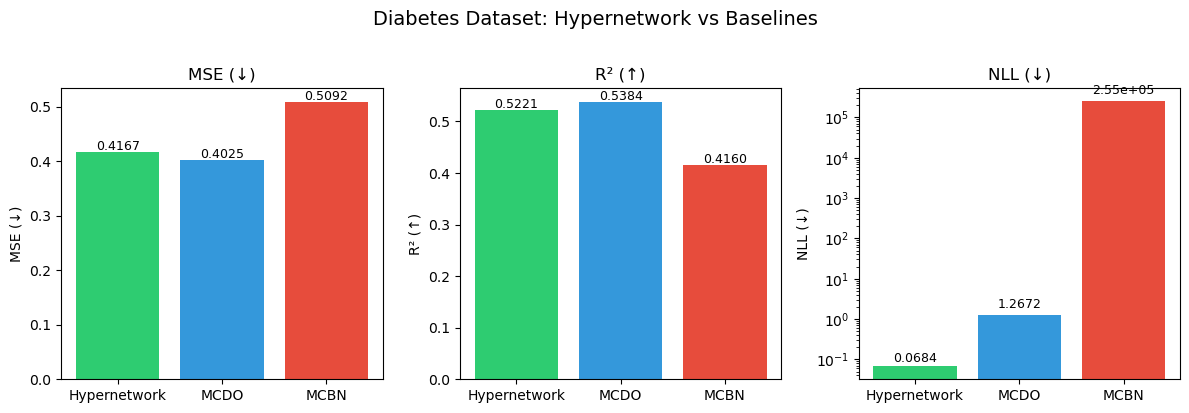

In [8]:
# Performance Comparison
results = {
    'Hypernetwork': hnet_results,
    'MCDO': mcdo_results,
    'MCBN': mcbn_results
}

metrics = ['mse', 'r2', 'nll']
metric_labels = ['MSE (↓)', 'R² (↑)', 'NLL (↓)']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ['#2ecc71', '#3498db', '#e74c3c']

for ax, metric, label in zip(axes, metrics, metric_labels):
    values = [results[name][metric] for name in results]
    bars = ax.bar(results.keys(), values, color=colors)
    ax.set_ylabel(label)
    ax.set_title(label)

    # Use log scale for NLL when values span multiple orders of magnitude
    if metric == 'nll' and max(values) / (min(values) + 1e-10) > 100:
        ax.set_yscale('log')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height() - 0.01
        fmt = f'{val:.4f}' if 0.001 < abs(val) < 10000 else f'{val:.2e}'
        ax.annotate(fmt, xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Diabetes Dataset: Hypernetwork vs Baselines', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()